# Gas Turbine Emission Prediction with CatBoost

This notebook builds a machine learning model to predict NOx (nitrogen oxide) emissions from gas turbines using the **CatBoost Regressor**. CatBoost is a gradient boosting library that handles categorical features efficiently and provides robust performance on regression tasks.

## Overview
- **Dataset**: Gas_Turbine_Co_NoX_2015.mat
- **Task**: Regression (predict continuous NOx emission values)
- **Model**: CatBoost Regressor
- **Evaluation Metrics**: MAE, SMAPE, MSE, R²

## Step 0: Import Required Libraries

We import essential libraries for data manipulation, machine learning, and visualization:
- **scipy.io**: For loading MATLAB files (.mat format)
- **pandas & numpy**: For data manipulation and numerical operations
- **CatBoost**: Our main regression model
- **sklearn**: For data splitting and metrics calculation
- **matplotlib & seaborn**: For data visualization

In [1]:
import scipy.io
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
# Load the dataset
file_path = 'Gas_Turbine_Co_NoX_2015.mat'
mat_data = scipy.io.loadmat(file_path)

# Extract features and labels
X = mat_data['feat']
y = mat_data['lbl2']

# Define meaningful feature names based on gas turbine operational parameters
# These represent various sensor readings and operational conditions
feature_names = [
    'AT',      # Ambient temperature (°C)
    'AP',      # Ambient pressure (mbar)
    'AH',      # Ambient humidity (%)
    'AFDP',    # Air filter difference pressure (mbar)
    'GTEP',    # Gas turbine exhaust pressure (mbar)
    'TIT',     # Turbine inlet temperature (°C)
    'TAT',     # Turbine after temperature (°C)
    'TEY',     # Turbine energy yield (MWH)
    'CDP',     # Compressor discharge pressure (mbar)
]

# Convert to pandas DataFrame for easier handling
df_X = pd.DataFrame(X, columns=feature_names)
df_y = pd.DataFrame(y, columns=['NOx_Emission'])

print(f"Features shape: {df_X.shape}")
print(f"Target shape: {df_y.shape}")
print(f"\nFeature names:")
for i, name in enumerate(feature_names, 1):
    print(f"  {i}. {name}")

Features shape: (7384, 9)
Target shape: (7384, 1)

Feature names:
  1. AT
  2. AP
  3. AH
  4. AFDP
  5. GTEP
  6. TIT
  7. TAT
  8. TEY
  9. CDP


The dataset is stored in MATLAB format (.mat). We load the file and extract:
- **X (Features)**: Input variables that describe operating conditions of the turbine
- **y (Target)**: NOx emission values we want to predict

We convert the raw arrays into a pandas DataFrame for easier data manipulation and to maintain feature names throughout the analysis.

## 2. Split and Prepare Data

We split the data into training and testing sets with an 80-20 split:
- **Training set (80%)**: Used to train the CatBoost model
- **Testing set (20%)**: Used to evaluate model performance on unseen data

This separation is crucial to assess how well the model generalizes to new data and avoid overfitting.

In [3]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df_X, df_y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 5907
Testing set size: 1477


## 3. Train CatBoost Model

**CatBoost** (Categorical Boosting) is a gradient boosting algorithm that:
- Handles categorical features natively without preprocessing
- Uses ordered boosting to reduce overfitting
- Provides stable and fast training

**Hyperparameters used:**
- **iterations=1000**: Number of boosting rounds (trees to build)
- **learning_rate=0.05**: Controls how much each tree contributes (lower = more conservative)
- **depth=8**: Maximum tree depth for feature interactions
- **loss_function='RMSE'**: Root Mean Squared Error for regression tasks

In [4]:
# Initialize and train the CatBoost Regressor
# You can tune parameters like iterations, learning_rate, depth, etc.
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function='RMSE',
    verbose=100  # Print training progress every 100 iterations
)

print("Starting training...")
model.fit(X_train, y_train)
print("Training completed!")

Starting training...
0:	learn: 10.6884503	total: 167ms	remaining: 2m 46s
100:	learn: 3.2752537	total: 1.46s	remaining: 13s
200:	learn: 2.8294140	total: 2.31s	remaining: 9.21s
300:	learn: 2.5426210	total: 3.16s	remaining: 7.34s
400:	learn: 2.3251722	total: 4.05s	remaining: 6.05s
500:	learn: 2.1449550	total: 5.1s	remaining: 5.08s
600:	learn: 2.0035741	total: 6.25s	remaining: 4.15s
700:	learn: 1.8804932	total: 7.2s	remaining: 3.07s
800:	learn: 1.7755921	total: 8.19s	remaining: 2.03s
900:	learn: 1.6900980	total: 9.14s	remaining: 1s
999:	learn: 1.6081031	total: 10.5s	remaining: 0us
Training completed!


## 4. Make Predictions

Now we use the trained model to generate predictions on the test set. Each prediction represents the model's estimated NOx emission value for a given set of turbine operating conditions.

In [5]:
# Make predictions on test set
predictions = model.predict(X_test)

print(f"Predictions shape: {predictions.shape}")
print(f"First 5 predictions: {predictions[:5]}")

Predictions shape: (1477,)
First 5 predictions: [53.27343572 60.519443   78.95295485 68.79527854 52.63093501]


## 5. Feature Importance

Feature importance shows which input variables had the most influence on the model's predictions. Higher scores indicate that a feature is more critical for predicting NOx emissions. This helps us understand which turbine operating conditions are the strongest drivers of emissions.

In [6]:
# Optional: Feature Importance
print("Feature Importance:")
feature_importances = model.get_feature_importance()
for score, name in sorted(zip(feature_importances, feature_names), reverse=True):
    print(f'{name}: {score:.4f}')

Feature Importance:
AT: 39.4247
AFDP: 13.9741
TAT: 12.6321
AH: 9.1203
TIT: 7.4874
GTEP: 6.3962
AP: 5.9793
TEY: 2.8678
CDP: 2.1182


## 6. Evaluation Metrics

We calculate key performance metrics to evaluate model accuracy:

**Metrics:**
- **MAE (Mean Absolute Error)**: Average absolute difference between actual and predicted NOx values
- **SMAPE (Symmetric Mean Absolute Percentage Error)**: Percentage-based error metric symmetric for over/underestimation

In [ ]:
# SMAPE function definition
def calculate_smape(actual, forecast):
    # Ensure inputs are flattened numpy arrays
    if hasattr(actual, 'values'):
        actual = actual.values
    actual = actual.flatten()
    forecast = forecast.flatten()
    
    return 100/len(actual) * np.sum(2 * np.abs(forecast - actual) / (np.abs(actual) + np.abs(forecast)))

# Calculate metrics
mae = mean_absolute_error(y_test, predictions)
smape_val = calculate_smape(y_test, predictions)

print(f"MAE (Mean Absolute Error): {mae:.4f}")
print(f"SMAPE (Symmetric Mean Absolute Percentage Error): {smape_val:.4f}%")

MAE (Mean Absolute Error): 2.0336
SMAPE (Symmetric Mean Absolute Percentage Error): 3.3802%


Here we compute the numerical performance metrics. The results will show us how well our model performs on the test set.

## 7. Model Evaluation Visualizations

Visual analysis helps us understand model behavior more intuitively. The following plots show:
1. **Feature Importance**: Which features drive predictions
2. **Actual vs Predicted**: How close predictions are to reality (scatter plot)
3. **Residuals Distribution**: Error patterns across predictions
4. **Trend Comparison**: How well the model captures temporal trends in the first 100 test samples

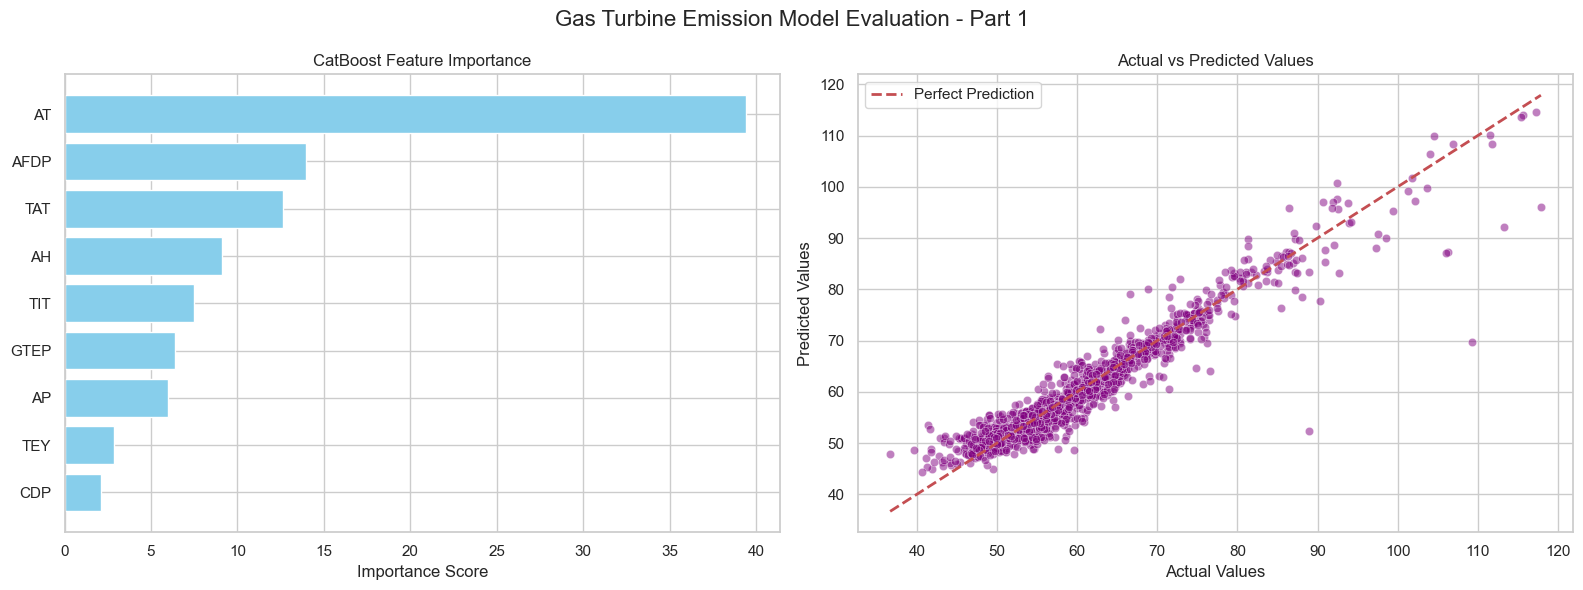

In [8]:
# Set a nice style for the plots
sns.set(style="whitegrid")

# Create a figure with subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Gas Turbine Emission Model Evaluation - Part 1', fontsize=16)

# --- Plot 1: Feature Importance (Bar Chart) ---
# Get importance and sort them
importance = model.get_feature_importance()
sorted_idx = np.argsort(importance)
# Plot
axes[0].barh(range(len(sorted_idx)), importance[sorted_idx], align='center', color='skyblue')
axes[0].set_yticks(range(len(sorted_idx)))
axes[0].set_yticklabels(np.array(feature_names)[sorted_idx])
axes[0].set_title('CatBoost Feature Importance')
axes[0].set_xlabel('Importance Score')

# --- Plot 2: Actual vs Predicted (Scatter Plot) ---
# Flatten y_test in case it's a dataframe
y_test_flat = y_test.values.flatten() if hasattr(y_test, 'values') else y_test
# Scatter plot
sns.scatterplot(x=y_test_flat, y=predictions, ax=axes[1], alpha=0.5, color='purple')
# Add a perfect prediction line (y=x)
min_val = min(y_test_flat.min(), predictions.min())
max_val = max(y_test_flat.max(), predictions.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[1].set_title('Actual vs Predicted Values')
axes[1].set_xlabel('Actual Values')
axes[1].set_ylabel('Predicted Values')
axes[1].legend()

plt.tight_layout()
plt.show()

### Part 1: Feature Importance & Actual vs Predicted
These two plots together show:
- **Left (Feature Importance)**: The relative importance of each feature in the model
- **Right (Scatter Plot)**: How well predictions match actual values. Points near the diagonal red line indicate accurate predictions.

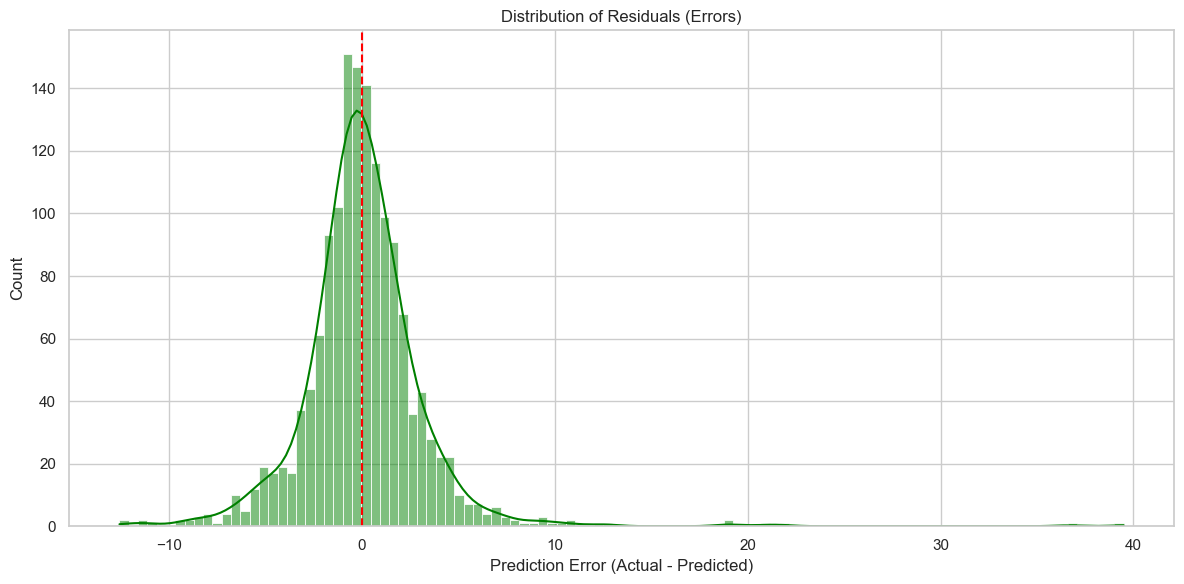

In [9]:
# --- Plot 3: Residuals Distribution (Histogram) ---
# Calculate residuals
y_test_flat = y_test.values.flatten() if hasattr(y_test, 'values') else y_test
residuals = y_test_flat - predictions

plt.figure(figsize=(12, 6))
sns.histplot(residuals, kde=True, color='green')
plt.title('Distribution of Residuals (Errors)')
plt.xlabel('Prediction Error (Actual - Predicted)')
plt.axvline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

### Part 2: Residuals Distribution
This histogram shows the distribution of prediction errors (residuals):
- **Centered at 0**: Indicates the model is not systematically biased (not consistently over/underpredicting)
- **Bell-shaped (Normal distribution)**: Suggests the errors follow a typical pattern and the model meets regression assumptions
- **Spread**: Wider spread indicates higher prediction uncertainty

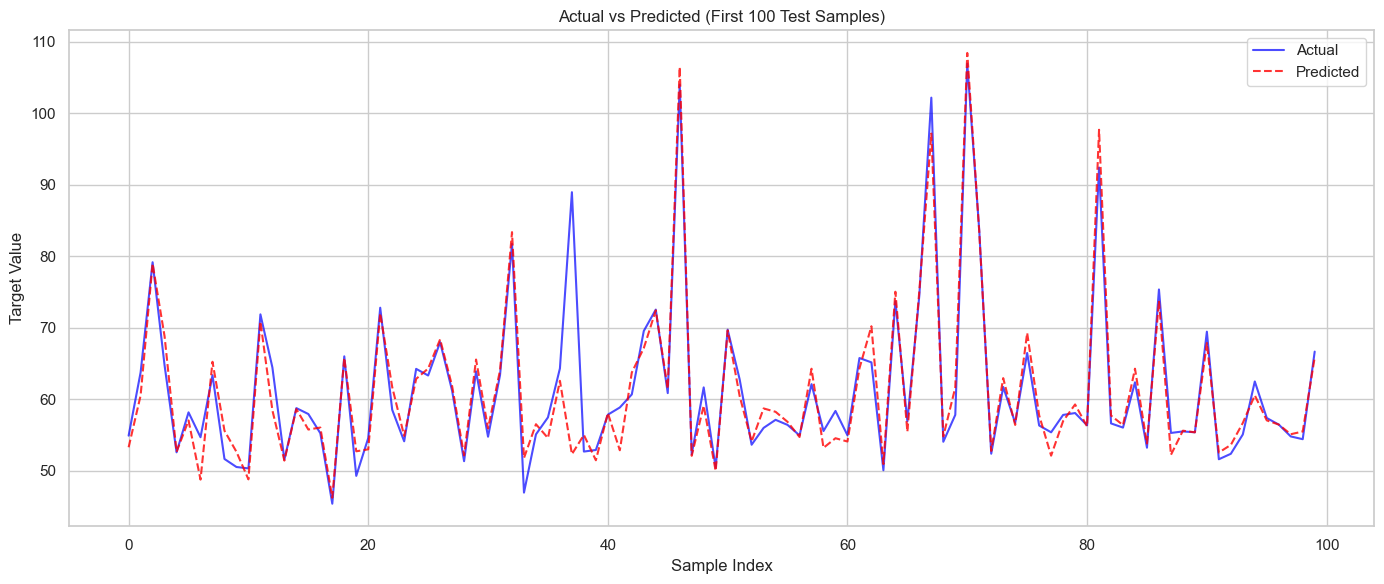

In [10]:
# --- Plot 4: Zoomed in Line Plot (First 100 samples) ---
# Useful to see how the model follows the trend
y_test_flat = y_test.values.flatten() if hasattr(y_test, 'values') else y_test
sample_range = 100

plt.figure(figsize=(14, 6))
plt.plot(y_test_flat[:sample_range], label='Actual', color='blue', alpha=0.7)
plt.plot(predictions[:sample_range], label='Predicted', color='red', linestyle='--', alpha=0.8)
plt.title(f'Actual vs Predicted (First {sample_range} Test Samples)')
plt.xlabel('Sample Index')
plt.ylabel('Target Value')
plt.legend()
plt.tight_layout()
plt.show()

### Part 3: Trend Comparison
This line plot compares actual vs predicted values for the first 100 test samples:
- **Blue line (Actual)**: Real NOx emission measurements
- **Red line (Predicted)**: Model predictions
- **Close alignment**: Indicates the model captures the underlying trends well
- **Divergence**: Where the model struggles to follow the actual pattern

## 8. Feature Correlation Analysis

The correlation heatmap reveals relationships between all features and the target variable:
- **Red colors**: Positive correlation (as feature increases, target increases)
- **Blue colors**: Negative correlation (as feature increases, target decreases)
- **Intensity**: Stronger colors indicate stronger correlations
- **Feature relationships**: Understanding correlations helps identify multicollinearity and feature redundancy

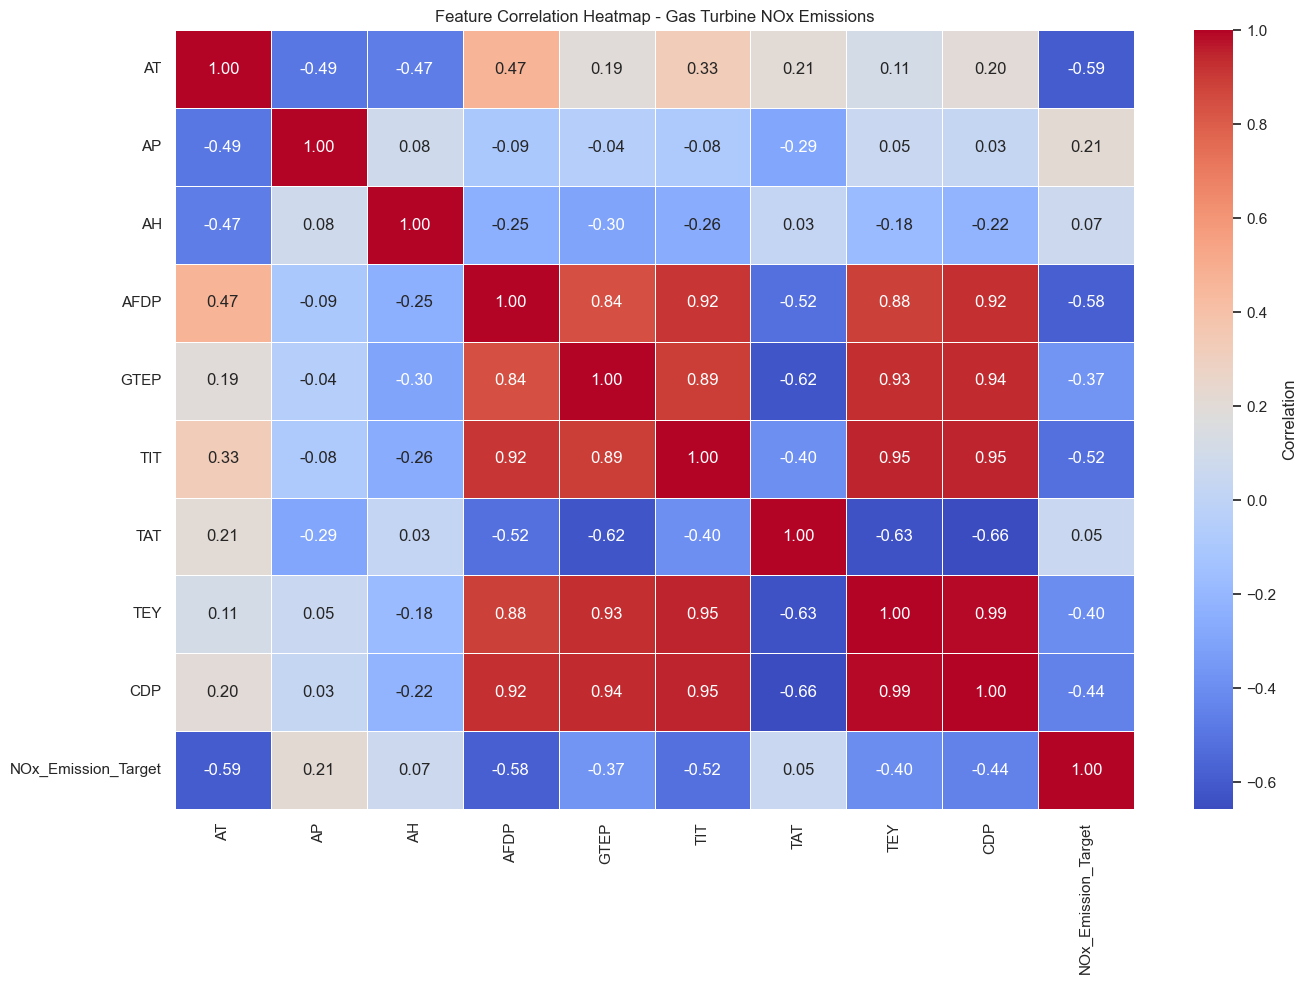

In [11]:
# Correlation Heatmap for Data Analysis
plt.figure(figsize=(14, 10))
# Combine X and y to see correlation with target
full_data = df_X.copy()
full_data['NOx_Emission_Target'] = df_y
correlation_matrix = full_data.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlation Heatmap - Gas Turbine NOx Emissions')
plt.tight_layout()
plt.show()